In [1]:
import rospy
import actionlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from geometry_msgs.msg import Twist
from nav_msgs.msg import Odometry
from assignment_2_2024.msg import PlanningAction, PlanningGoal
from rt1_assignment2_p1.msg import RobotStatus
from rt1_assignment2_p1.srv import GetLastTarget
from actionlib_msgs.msg import GoalStatusArray
from IPython.display import display
import ipywidgets as widgets

In [2]:
# Initialize ROS node
rospy.init_node('jupyter_action_client', anonymous=True)

In [3]:
# Globals
current_feedback = {'x': 0.0, 'y': 0.0, 'status': ""}
positions_x, positions_y = [5], [5]
reached_count = 0
not_reached_count = 0
current_goal_active = False
closest_obstacle_distance = widgets.Label(value="Closest obstacle: Unknown")

In [4]:
# Create Action Client
client = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)
client.wait_for_server()

True

In [5]:
# Publisher
status_pub = rospy.Publisher('/robot_status', RobotStatus, queue_size=10)

In [6]:
# Widgets for Interface
x_goal = widgets.FloatText(description='X Goal:')
y_goal = widgets.FloatText(description='Y Goal:')
set_button = widgets.Button(description='Set Goal', button_style='success')
cancel_button = widgets.Button(description='Cancel Goal', button_style='danger')
output_area = widgets.Output()

In [7]:
def send_goal(x: float, y: float) -> None:
    goal = PlanningGoal()
    goal.target_pose.pose.position.x = x
    goal.target_pose.pose.position.y = y
    client.send_goal(goal, done_cb=goal_done_callback, feedback_cb=goal_feedback_callback)
    set_last_target(x, y)
    with log_output:
        print(f"Sent goal: x={x}, y={y}")
    current_goal_active = True
    

def cancel_goal() -> None:
    global client, current_goal_active, not_reached_count
    client.cancel_goal()
    current_goal_active = False
    not_reached_count += 1
    with log_output:
        print("Goal canceled.")

def goal_done_callback(status, result):
    global reached_count, not_reached_count, current_goal_active
    with log_output:
        if status == actionlib.GoalStatus.SUCCEEDED:
            reached_count += 1
            print("Goal achieved successfully.")
        else:
            not_reached_count += 1
            print("Goal did not complete successfully.")
    current_goal_active = False

def goal_feedback_callback(feedback):
    current_feedback['x'] = feedback.actual_pose.position.x
    current_feedback['y'] = feedback.actual_pose.position.y
    current_feedback['status'] = feedback.stat

def get_last_target():
    rospy.wait_for_service('/get_last_target')
    try:
        proxy = rospy.ServiceProxy('/get_last_target', GetLastTarget)
        resp = proxy(False, 0, 0)
        with log_output:
            print(f"Last target: x={resp.res_x}, y={resp.res_y}")
    except rospy.ServiceException as e:
        with log_output:
            print(f"Service call failed: {e}")

def set_last_target(x: float, y: float) -> None:
    rospy.wait_for_service('/get_last_target')
    try:
        proxy = rospy.ServiceProxy('/get_last_target', GetLastTarget)
        resp = proxy(True, x, y)
        if resp.success:
            with log_output:
                print("Last target successfully updated.")
    except rospy.ServiceException as e:
        with log_output:
            print(f"Service call failed: {e}")


In [8]:
x_input = widgets.FloatText(description="X:", value=0.0)
y_input = widgets.FloatText(description="Y:", value=0.0)
send_btn = widgets.Button(description="Send Goal")
cancel_btn = widgets.Button(description="Cancel")
status_btn = widgets.Button(description="Status")
feedback_btn = widgets.Button(description="Feedback")
last_btn = widgets.Button(description="Last Target")
clear_btn = widgets.Button(description="Clear Log")
log_output = widgets.Output(layout={"border": "1px solid black", "height": "200px", "overflow_y": "scroll"})


In [9]:
def on_send_clicked(_):
    if client.get_state() == actionlib.GoalStatus.ACTIVE:
        with log_output:
            print("A goal is currently active. Cancel it first.")
    else:
        send_goal(x_input.value, y_input.value)

def on_cancel_clicked(_):
    cancel_goal()

def on_status_clicked(_):
    if client.get_state() == actionlib.GoalStatus.ACTIVE:
        with log_output:
            print(f"Current status: {current_feedback['status']}")
    else:
        with log_output:
            print("No active goal.")

def on_feedback_clicked(_):
    if client.get_state() == actionlib.GoalStatus.ACTIVE:
        x = current_feedback['x']
        y = current_feedback['y']
        with log_output:
            print(f"Current feedback position: x={x}, y={y}")
    else:
        with log_output:
            print("No active goal.")

def on_last_clicked(_):
    get_last_target()

def on_clear_clicked(_):
    log_output.clear_output()


In [10]:
send_btn.on_click(on_send_clicked)
cancel_btn.on_click(on_cancel_clicked)
status_btn.on_click(on_status_clicked)
feedback_btn.on_click(on_feedback_clicked)
last_btn.on_click(on_last_clicked)
clear_btn.on_click(on_clear_clicked)

controls = widgets.VBox([
    widgets.HBox([x_input, y_input, send_btn]),
    widgets.HBox([cancel_btn, status_btn, feedback_btn, last_btn, clear_btn]),
    log_output
])

display(controls)


Widget Javascript not detected.  It may not be installed or enabled properly.


In [11]:
# Obstacle Distance Mock (Replace with your sensor input if available)
def distance_to_closest_obstacle():
    return np.random.uniform(0.2, 5.0)  # Mocking random distances

Text(0, 0.5, 'y')

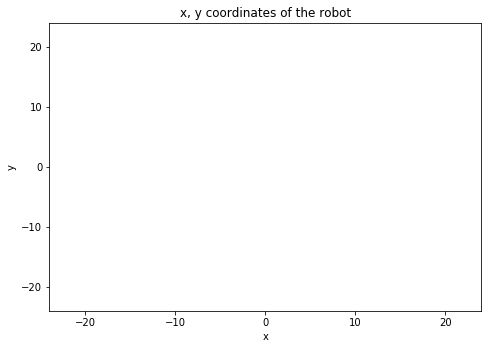

In [12]:
np_pos_x = np.array(positions_x)
np_pos_y = np.array(positions_y)
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_xlim(-24, 24)
ax.set_ylim(-24, 24)
ax.plot(np_pos_x, np_pos_y)
ax.set_title("x, y coordinates of the robot")
ax.set_xlabel("x")
ax.set_ylabel("y")

In [13]:
%matplotlib notebook

def plot(x_plot, y_plot):
    np_x_plot = np.array(x_plot)
    np_y_plot = np.array(y_plot)
    ax.plot(np_x_plot, np_y_plot)

def odom_callback(msg: Odometry):
    global positions_x, positions_y

    position = msg.pose.pose.position
    velocity = msg.twist.twist

    status_msg = RobotStatus()
    status_msg.x = position.x
    status_msg.y = position.y
    status_msg.vel_x = velocity.linear.x
    status_msg.vel_z = velocity.angular.z
    positions_x.append(position.x)
    positions_y.append(position.y)
    plot(positions_x, positions_y)
    status_pub.publish(status_msg)

rospy.Subscriber('/odom', Odometry, odom_callback)



<IPython.core.display.Javascript object>


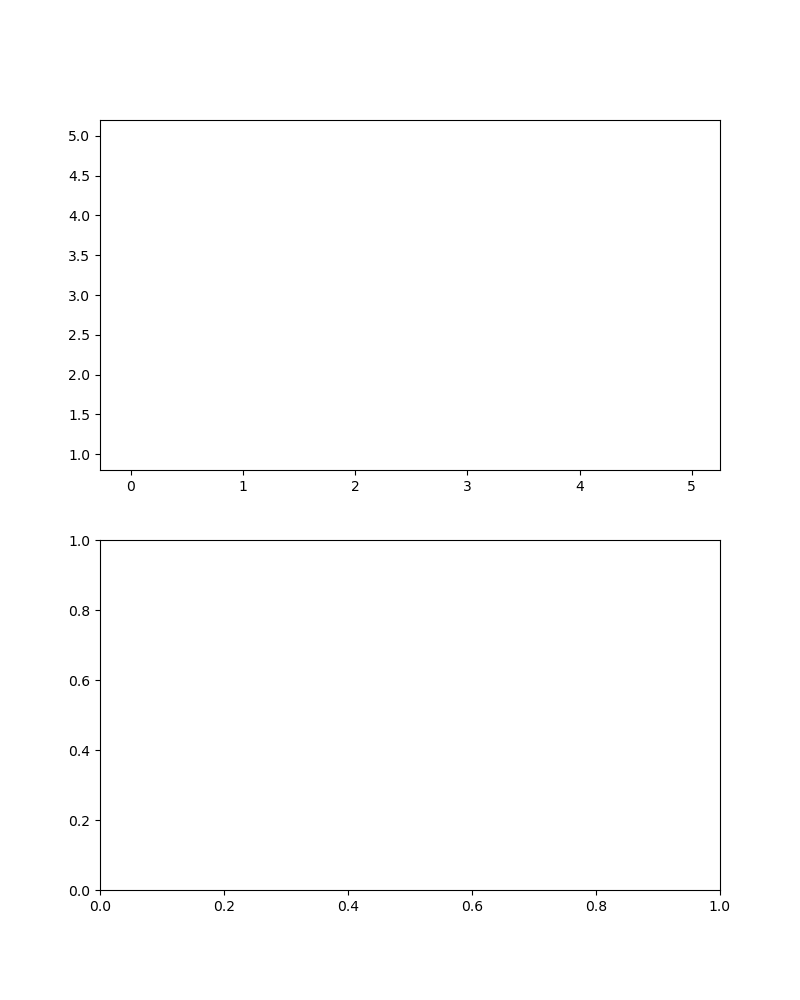

In [14]:
# Animation for robot position
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
np_x_plot = np.array(positions_x)
np_y_plot = np.array(positions_y)
line, = ax1.plot(np_x_plot, np_y_plot, animated=True)

bar_container = None


In [15]:
# Initialization

def init():

    line.set_data(np_x_plot, np_y_plot)

    for bar in bars:

        bar.set_height(0)

    return line, *bars

In [16]:
# Update function for animation

def update(frame):

    # Update positions (example logic; replace with actual data update)

    
    line.set_data(np_x_plot, np_y_plot)

 

    # Update counts (example logic; replace with actual data update)

    #global reached_count, not_reached_count

    # Update bar heights

    bars[0].set_height(reached_count)

    bars[1].set_height(not_reached_count)

 

    return line, *bars

In [17]:
ani = FuncAnimation(fig, update, init_func=init, interval=100)
plt.show()